# External Validation Results

Analysis of S1 (zero-shot transfer) and S3 (within-dataset CV)
results on the four UCI Heart Disease clinical datasets.
Reproduces Tables 4-5 from the paper.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Zero-Shot Transfer (S1)

In [2]:
ext_dir = Path('../results/external')

# Load S1 results
with open(ext_dir / 'zero_shot_transfer.json') as f:
    s1_data = json.load(f)

s1_df = pd.DataFrame(s1_data)
s1_df['auc'] = s1_df['metrics'].apply(lambda m: m['auc'])
s1_df['pr_auc'] = s1_df['metrics'].apply(lambda m: m['pr_auc'])

# Pivot: models x datasets
s1_pivot = s1_df.pivot_table(index='model', columns='dataset', values='auc')
s1_pivot = s1_pivot.sort_values('cleveland', ascending=False)
print('S1 Zero-Shot AUC (model trained on 630K, tested on UCI):')
s1_pivot.round(4)

S1 Zero-Shot AUC (model trained on 630K, tested on UCI):


dataset,cleveland,hungarian,switzerland,va_longbeach
model,,,,
pytorch_mlp,0.9193,0.8694,0.7283,0.7137
random_forest,0.9177,0.8847,0.7337,0.6920
ensemble_rank_blend_raw,0.9161,0.8662,0.7397,0.7125
catboost,0.9153,0.8589,0.7234,0.6988
xgboost,0.9153,0.8460,0.7261,0.7032
ensemble_rank_blend_stats,0.9128,0.8359,0.7272,0.6915
lightgbm,0.9115,0.8407,0.7375,0.6920
knn,0.9106,0.8889,0.6783,0.6368
logistic_regression,0.9094,0.8636,0.6543,0.6906


## 2. Within-Dataset CV (S3)

In [3]:
# Load S3 results
s3_path = ext_dir / 'within_cv_scenario3.json'
if s3_path.exists():
    with open(s3_path) as f:
        s3_data = json.load(f)
    s3_df = pd.DataFrame(s3_data)
    
    # Best config per model/dataset (across tuning and imbalance)
    s3_best = s3_df.sort_values('oof_auc', ascending=False).drop_duplicates(
        subset=['model', 'dataset'], keep='first')
    s3_pivot = s3_best.pivot_table(index='model', columns='dataset', values='oof_auc')
    s3_pivot = s3_pivot.sort_values('cleveland', ascending=False)
    print('S3 Within-Dataset Best AUC per Family:')
    display(s3_pivot.round(4))
else:
    print('S3 results not yet available')

S3 Within-Dataset Best AUC per Family:


dataset,cleveland,hungarian,switzerland,va_longbeach
model,,,,
lightgbm,0.9157,0.8847,0.8587,0.7292
knn,0.9131,0.8941,0.7136,0.7004
tabpfn,0.9129,0.9199,0.7141,0.6723
ridge,0.9081,0.9011,0.7087,0.6794
random_forest,0.9077,0.8893,0.7500,0.7165
svm,0.9048,0.9066,0.6902,0.6839
logistic_regression,0.9047,0.9033,0.7065,0.6673
extra_trees,0.9045,0.9107,0.7511,0.7165
elastic_net,0.9042,0.9029,0.7880,0.6765


## 3. S1 vs S3 Comparison

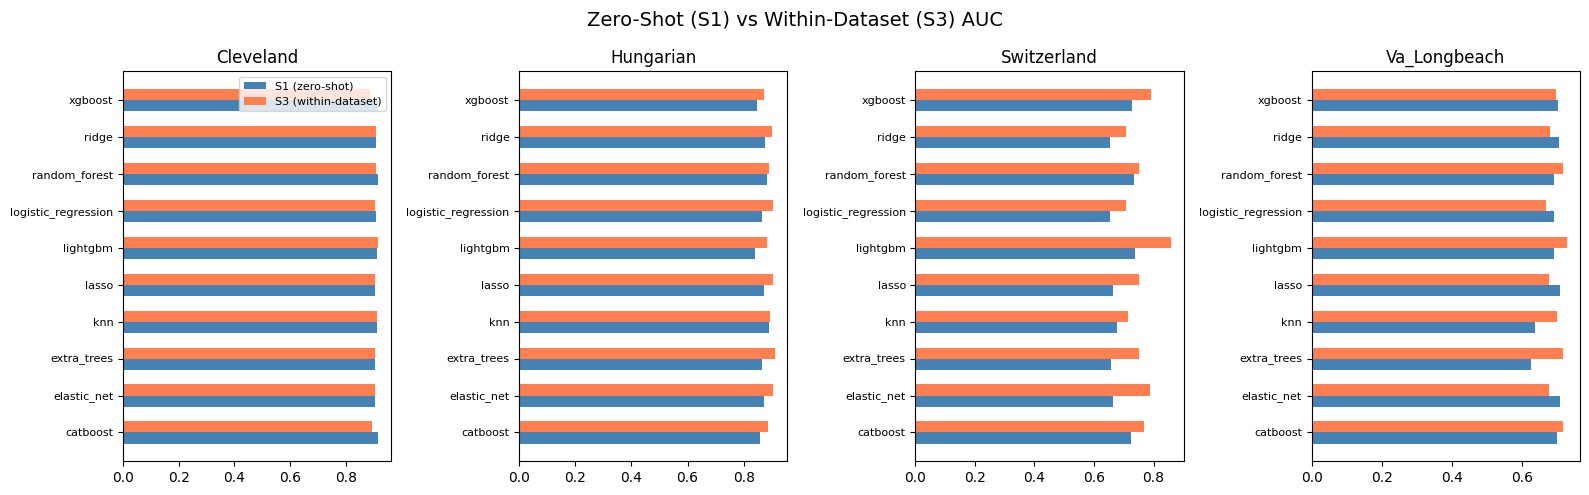

In [4]:
# Side-by-side comparison for each dataset
if s3_path.exists():
    datasets = ['cleveland', 'hungarian', 'switzerland', 'va_longbeach']
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    
    for i, ds in enumerate(datasets):
        ax = axes[i]
        s1_vals = s1_pivot[ds].dropna() if ds in s1_pivot.columns else pd.Series()
        s3_vals = s3_pivot[ds].dropna() if ds in s3_pivot.columns else pd.Series()
        
        common = sorted(set(s1_vals.index) & set(s3_vals.index))
        if common:
            x = range(len(common))
            ax.barh([xi - 0.15 for xi in x], [s1_vals.get(m, 0) for m in common],
                    height=0.3, label='S1 (zero-shot)', color='steelblue')
            ax.barh([xi + 0.15 for xi in x], [s3_vals.get(m, 0) for m in common],
                    height=0.3, label='S3 (within-dataset)', color='coral')
            ax.set_yticks(x)
            ax.set_yticklabels(common, fontsize=8)
        ax.set_title(ds.title())
        if i == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle('Zero-Shot (S1) vs Within-Dataset (S3) AUC', fontsize=14)
    plt.tight_layout()
    plt.savefig('../results/figures/s1_vs_s3_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Ensemble Transfer (05b)

In [5]:
ens_path = ext_dir / 'ensemble_diverse_models.json'
if ens_path.exists():
    with open(ens_path) as f:
        ens_data = json.load(f)
    ens_df = pd.DataFrame(ens_data)
    print('Diverse Model Ensemble Results:')
    display(ens_df[['dataset', 'method', 'auc', 'pr_auc', 'n_models']].to_string(index=False))
else:
    print('Ensemble transfer results not yet available')

Diverse Model Ensemble Results:


'     dataset                     method      auc  pr_auc  n_models\n   cleveland            single_catboost 0.896166  0.8886         1\n   cleveland         single_elastic_net 0.904238  0.8978         1\n   cleveland         single_extra_trees 0.904545  0.8907         1\n   cleveland                 single_knn 0.913143  0.9036         1\n   cleveland               single_lasso 0.904194  0.8974         1\n   cleveland            single_lightgbm 0.915731  0.9156         1\n   cleveland single_logistic_regression 0.904720  0.8985         1\n   cleveland                 single_mlp 0.901606  0.8879         1\n   cleveland       single_random_forest 0.907659  0.9015         1\n   cleveland             single_realmlp 0.894587  0.8917         1\n   cleveland               single_ridge 0.908098  0.9053         1\n   cleveland                 single_svm 0.904808  0.9030         1\n   cleveland              single_tabpfn 0.912879  0.9019         1\n   cleveland             single_xgboost 0.88754

## Summary

- Zero-shot transfer works well on Cleveland (n=303, most similar to training distribution)
- Within-dataset CV generally outperforms zero-shot on all datasets
- Switzerland (n=123, 93.5% prevalence) is challenging for all approaches
- Ensemble diversity consistently helps on external data